# Final Pipeline Explanation

The final pipeline combines grocery image classification with nutrition retrieval.

The system supports two datasets:

1. Freiburg Groceries dataset  
2. Egyptian Products dataset  

Every time the notebook runs, it randomly selects images from both datasets.

For dataset testing, the full image is sent directly to the classifier because most dataset images are already centered and contain one main product.

YOLO is not used in this final dataset-testing pipeline because pretrained YOLOv8 is trained on COCO classes, not grocery-specific classes. It may detect object regions, but its labels can be incorrect for supermarket products.

The classifier is responsible for predicting the grocery/product class.

Pipeline steps:

1. Select random image
2. Choose the correct classifier based on dataset source
3. Resize image to 224×224
4. Predict product class using ResNet50
5. Check if product is food
6. If food, call USDA nutrition API
7. Display prediction, confidence, and nutrition information

For real-world webcam or supermarket shelf images, YOLO can still be used before the classifier to localize products.

In [42]:
import os
from pathlib import Path
import random
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

os.chdir(r"C:\Users\Asus\grocery-cv-project")

print("Current directory:", os.getcwd())

Current directory: C:\Users\Asus\grocery-cv-project


In [43]:
from src.nutrition_api import get_nutrition

In [44]:
FREIBURG_IMAGE_DIR = Path("data/raw/freiburg_groceries/images")

EGYPT_IMAGE_DIR = Path(
    "data/raw/egyptain_food/Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip/train"
)

FREIBURG_MODEL_PATH = Path("models/resnet50_grocery.keras")
EGYPT_MODEL_PATH = Path("models/egyptian_resnet50_model.keras")

FREIBURG_MODEL_PATH = Path("models/freiburg_resnet50_model.keras")
EGYPT_CLASSES_PATH = Path("models/egyptian_class_names.json")

print("Freiburg images:", FREIBURG_IMAGE_DIR.exists())
print("Egyptian images:", EGYPT_IMAGE_DIR.exists())
print("Freiburg model:", FREIBURG_MODEL_PATH.exists())
print("Egyptian model:", EGYPT_MODEL_PATH.exists())

Freiburg images: True
Egyptian images: True
Freiburg model: True
Egyptian model: True


In [46]:
from pathlib import Path
import json
import os

os.chdir(r"C:\Users\Asus\grocery-cv-project")

FREIBURG_DIR = Path("data/raw/freiburg_groceries/images")

EGYPT_DIR = Path(
    "data/raw/egyptain_food/Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip/train"
)

freiburg_class_names = sorted([p.name for p in FREIBURG_DIR.iterdir() if p.is_dir()])
egypt_class_names = sorted([p.name for p in EGYPT_DIR.iterdir() if p.is_dir()])

print("Freiburg classes:", len(freiburg_class_names))
print(freiburg_class_names)

print("Egyptian classes:", len(egypt_class_names))
print(egypt_class_names)

Path("models").mkdir(exist_ok=True)

with open("models/freiburg_class_names.json", "w") as f:
    json.dump(freiburg_class_names, f)

with open("models/egyptian_class_names.json", "w") as f:
    json.dump(egypt_class_names, f)

print("Class name files fixed.")

Freiburg classes: 25
['BEANS', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'FISH', 'FLOUR', 'HONEY', 'JAM', 'JUICE', 'MILK', 'NUTS', 'OIL', 'PASTA', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'TEA', 'TOMATO_SAUCE', 'VINEGAR', 'WATER']
Egyptian classes: 8
['Bisco Misr Luxe Original Plain Biscuits Extra size', 'Bisco Misr Max Tea Biscuits', 'Bisco Misr Wafer Vanilla Big', 'Heinz Tomato Ketchup Grill', 'Oniro Teabix Biscuits', 'Shepsy Salt and Vinegar Chips', 'Shepsy Tomato Chips', 'Signal Cavity Fighter']
Class name files fixed.


In [47]:
def collect_images(folder):
    image_extensions = ["*.jpg", "*.jpeg", "*.png"]
    images = []

    for ext in image_extensions:
        images.extend(list(folder.rglob(ext)))

    return images


freiburg_images = collect_images(FREIBURG_IMAGE_DIR)
egypt_images = collect_images(EGYPT_IMAGE_DIR)

print("Freiburg images found:", len(freiburg_images))
print("Egyptian images found:", len(egypt_images))

random_freiburg = random.sample(freiburg_images, min(5, len(freiburg_images)))
random_egypt = random.sample(egypt_images, min(5, len(egypt_images)))

test_images = []

for img in random_freiburg:
    test_images.append({
        "path": img,
        "dataset": "Freiburg"
    })

for img in random_egypt:
    test_images.append({
        "path": img,
        "dataset": "Egyptian"
    })

random.shuffle(test_images)

for item in test_images:
    print(item["dataset"], "→", item["path"])

Freiburg images found: 4947
Egyptian images found: 353
Egyptian → data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Bisco Misr Wafer Vanilla Big\20250310_124243_jpg.rf.f87f6df814652a1c79f28114299b2995.jpg
Freiburg → data\raw\freiburg_groceries\images\JUICE\JUICE0035.png
Freiburg → data\raw\freiburg_groceries\images\HONEY\HONEY0127.png
Freiburg → data\raw\freiburg_groceries\images\WATER\WATER0235.png
Egyptian → data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Shepsy Tomato Chips\20250330_221436_jpg.rf.840b431809d8d6076d8fe80dad3655d6.jpg
Egyptian → data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Bisco Misr Luxe Original Plain Biscuits Extra size\20250310_134735_jpg.rf.51aca83eb4e6e0fbf33f243e5e57d6b5.jpg
Freiburg → data\raw\freiburg_groceries\images\HONEY\HONEY0017.png
Freiburg → data\raw\freiburg_groceries\images\SPICES\SPICES0082.png
Egyptian → data\raw\egyptain_food\Eg

In [48]:
def preprocess_image(image):
    image = image.convert("RGB")
    image = image.resize((224, 224))

    arr = tf.keras.utils.img_to_array(image)
    arr = np.expand_dims(arr, axis=0)

    return arr


def predict_with_model(image_path, model, class_names):
    image = Image.open(image_path).convert("RGB")

    arr = preprocess_image(image)

    preds = model.predict(arr, verbose=0)

    pred_index = int(np.argmax(preds[0]))
    confidence = float(preds[0][pred_index])

    predicted_class = class_names[pred_index]

    return predicted_class, confidence, image

In [49]:
NON_FOOD_KEYWORDS = [
    "lifebuoy",
    "soap",
    "toothpaste",
    "toothbrush",
    "detergent",
    "shampoo",
    "cleaner",
    "cream",
    "lotion"
]


def is_food_product(class_name):
    name = class_name.lower()

    for word in NON_FOOD_KEYWORDS:
        if word in name:
            return False

    return True


def get_safe_nutrition(class_name):
    if not is_food_product(class_name):
        return {
            "status": "Skipped",
            "reason": "Non-food product, nutrition API not used"
        }

    try:
        nutrition = get_nutrition(class_name)
        return nutrition

    except Exception as e:
        return {
            "status": "Error",
            "reason": str(e)
        }

In [50]:
def run_final_pipeline(image_path, dataset_name):
    image_path = Path(image_path)

    if dataset_name == "Freiburg":
        model = freiburg_model
        class_names = freiburg_class_names
        mode = "Freiburg classifier"

    elif dataset_name == "Egyptian":
        model = egypt_model
        class_names = egypt_class_names
        mode = "Egyptian classifier"

    else:
        raise ValueError("Unknown dataset name")

    predicted_class, confidence, image = predict_with_model(
        image_path,
        model,
        class_names
    )

    nutrition = get_safe_nutrition(predicted_class)

    return {
        "image_path": image_path,
        "dataset": dataset_name,
        "mode": mode,
        "image": image,
        "prediction": predicted_class,
        "confidence": confidence,
        "nutrition": nutrition
    }

In [51]:
pipeline_results = []

for item in test_images:
    result = run_final_pipeline(
        image_path=item["path"],
        dataset_name=item["dataset"]
    )

    pipeline_results.append(result)

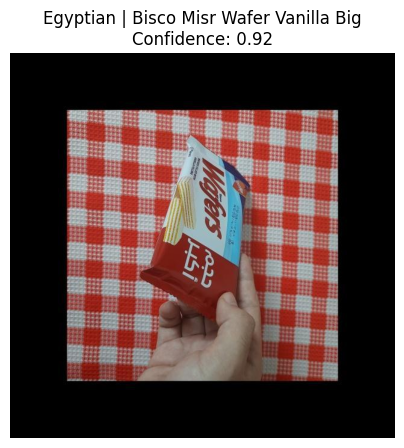

Dataset: Egyptian
Classifier used: Egyptian classifier
Image: data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Bisco Misr Wafer Vanilla Big\20250310_124243_jpg.rf.f87f6df814652a1c79f28114299b2995.jpg
Prediction: Bisco Misr Wafer Vanilla Big
Confidence: 0.921
Nutrition: {'calories': 455, 'protein': 4.9, 'fat': 16.41, 'carbs': 72.6}
----------------------------------------------------------------------


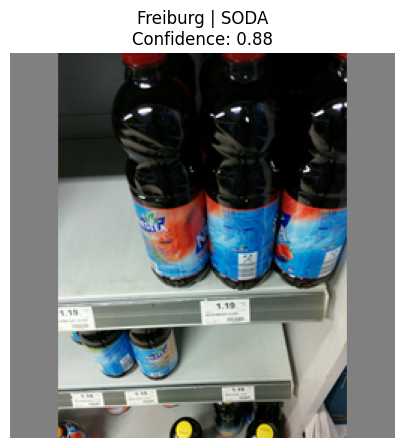

Dataset: Freiburg
Classifier used: Freiburg classifier
Image: data\raw\freiburg_groceries\images\JUICE\JUICE0035.png
Prediction: SODA
Confidence: 0.881
Nutrition: {'calories': 25.0, 'protein': 0.0, 'fat': 0.0, 'carbs': 6.76}
----------------------------------------------------------------------


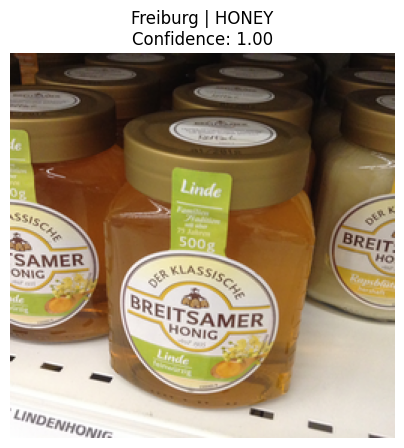

Dataset: Freiburg
Classifier used: Freiburg classifier
Image: data\raw\freiburg_groceries\images\HONEY\HONEY0127.png
Prediction: HONEY
Confidence: 0.997
Nutrition: {'calories': 304, 'protein': 0.3, 'fat': 0, 'carbs': 82.4}
----------------------------------------------------------------------


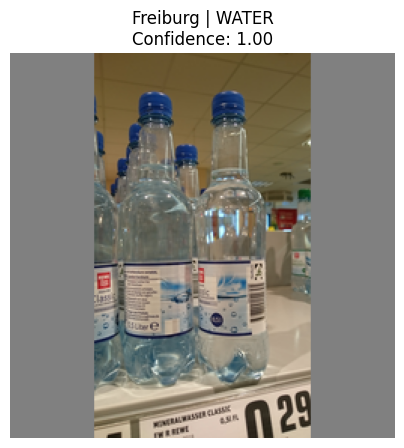

Dataset: Freiburg
Classifier used: Freiburg classifier
Image: data\raw\freiburg_groceries\images\WATER\WATER0235.png
Prediction: WATER
Confidence: 0.999
Nutrition: {'calories': 42.0, 'protein': 0.0, 'fat': 0.0, 'carbs': 10.8}
----------------------------------------------------------------------


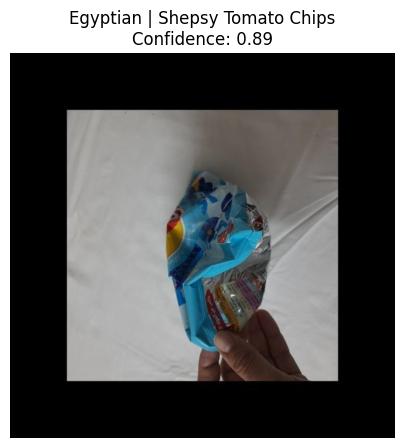

Dataset: Egyptian
Classifier used: Egyptian classifier
Image: data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Shepsy Tomato Chips\20250330_221436_jpg.rf.840b431809d8d6076d8fe80dad3655d6.jpg
Prediction: Shepsy Tomato Chips
Confidence: 0.895
Nutrition: {'calories': 20, 'protein': 0.82, 'fat': 0.31, 'carbs': 4.04}
----------------------------------------------------------------------


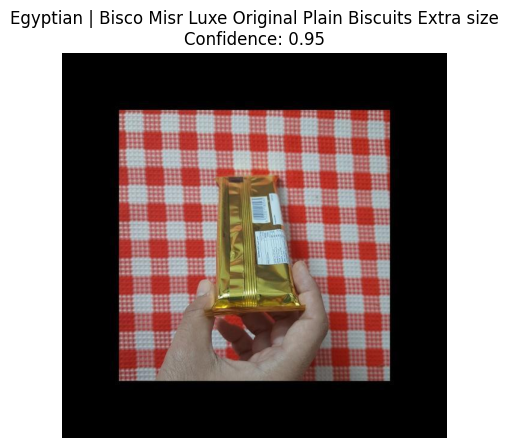

Dataset: Egyptian
Classifier used: Egyptian classifier
Image: data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Bisco Misr Luxe Original Plain Biscuits Extra size\20250310_134735_jpg.rf.51aca83eb4e6e0fbf33f243e5e57d6b5.jpg
Prediction: Bisco Misr Luxe Original Plain Biscuits Extra size
Confidence: 0.95
Nutrition: {'calories': 428, 'protein': 8.0, 'fat': 15.4, 'carbs': 63.4}
----------------------------------------------------------------------


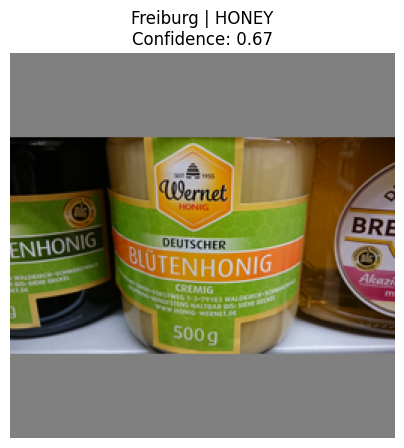

Dataset: Freiburg
Classifier used: Freiburg classifier
Image: data\raw\freiburg_groceries\images\HONEY\HONEY0017.png
Prediction: HONEY
Confidence: 0.673
Nutrition: {'calories': 304, 'protein': 0.3, 'fat': 0, 'carbs': 82.4}
----------------------------------------------------------------------


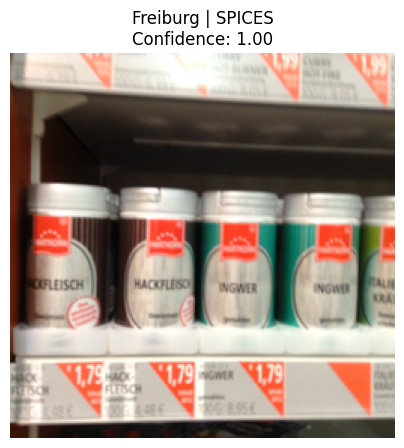

Dataset: Freiburg
Classifier used: Freiburg classifier
Image: data\raw\freiburg_groceries\images\SPICES\SPICES0082.png
Prediction: SPICES
Confidence: 0.997
Nutrition: {'calories': 333, 'protein': 0.0, 'fat': 0.0, 'carbs': 66.7}
----------------------------------------------------------------------


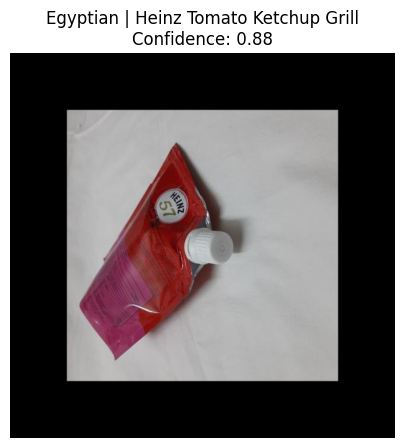

Dataset: Egyptian
Classifier used: Egyptian classifier
Image: data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Heinz Tomato Ketchup Grill\20250517_141654_jpg.rf.8085de1e1f1ad604b7206e3470f94524.jpg
Prediction: Heinz Tomato Ketchup Grill
Confidence: 0.883
Nutrition: {'calories': 118, 'protein': 0.0, 'fat': 0.0, 'carbs': 29.4}
----------------------------------------------------------------------


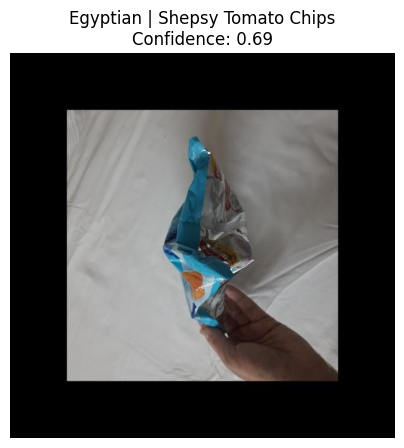

Dataset: Egyptian
Classifier used: Egyptian classifier
Image: data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Shepsy Tomato Chips\20250330_221533_jpg.rf.2a37a9ba86d9f8ef852c07bf96a9c996.jpg
Prediction: Shepsy Tomato Chips
Confidence: 0.695
Nutrition: {'calories': 20, 'protein': 0.82, 'fat': 0.31, 'carbs': 4.04}
----------------------------------------------------------------------


In [52]:
for result in pipeline_results:
    plt.figure(figsize=(5, 5))
    plt.imshow(result["image"])
    plt.axis("off")

    plt.title(
        f"{result['dataset']} | {result['prediction']}\n"
        f"Confidence: {result['confidence']:.2f}"
    )

    plt.show()

    print("Dataset:", result["dataset"])
    print("Classifier used:", result["mode"])
    print("Image:", result["image_path"])
    print("Prediction:", result["prediction"])
    print("Confidence:", round(result["confidence"], 3))
    print("Nutrition:", result["nutrition"])
    print("-" * 70)